# Análise k=1: MASTER, TFB e benchmarks

Fixa `janela_trading = k = 1`, em linha com a comparação de losses do paper **On Evaluating Loss Functions for Stock Ranking**.

No MASTER, normalmente `k = h`; logo `k=1` equivale a `pred_len/h=1`. No TFB, `k=1` pode coexistir com vários `pred_len`.


In [1]:
from pathlib import Path
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'utils':
    ROOT = ROOT.parent
if ROOT.name != 'paralelo' and (ROOT / 'paralelo').exists():
    ROOT = ROOT / 'paralelo'

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.comparativo_metricas_global import comparar_global

OUT = ROOT / 'simulacoes' / 'comparativo_global_master_tfb'
OUT.mkdir(parents=True, exist_ok=True)
OUT


PosixPath('/sonic_home/igor.viveiros/paralelo/simulacoes/comparativo_global_master_tfb')

In [2]:
dfs = comparar_global(
    base_dir=ROOT,
    output_dir='simulacoes/comparativo_global_master_tfb',
    top_n=30,
)
metricas = dfs['metricas'].copy()
print(f'Linhas carregadas: {len(metricas)}')
metricas.head()


/sonic_home/igor.viveiros/paralelo/utils/auc_direcional.py:87: RuntimeWarning: Mean of empty slice
  "auc_alta_media_janela": float(np.nanmean(auc_alta_janelas)) if auc_alta_janelas else np.nan,
/sonic_home/igor.viveiros/paralelo/utils/auc_direcional.py:88: RuntimeWarning: Mean of empty slice
  "auc_queda_media_janela": float(np.nanmean(auc_queda_janelas)) if auc_queda_janelas else np.nan,
/sonic_home/igor.viveiros/paralelo/utils/auc_direcional.py:87: RuntimeWarning: Mean of empty slice
  "auc_alta_media_janela": float(np.nanmean(auc_alta_janelas)) if auc_alta_janelas else np.nan,
/sonic_home/igor.viveiros/paralelo/utils/auc_direcional.py:88: RuntimeWarning: Mean of empty slice
  "auc_queda_media_janela": float(np.nanmean(auc_queda_janelas)) if auc_queda_janelas else np.nan,
/sonic_home/igor.viveiros/paralelo/utils/auc_direcional.py:87: RuntimeWarning: Mean of empty slice
  "auc_alta_media_janela": float(np.nanmean(auc_alta_janelas)) if auc_alta_janelas else np.nan,
/sonic_home/igor.vi

Linhas carregadas: 1062


,grupo,dataset,modelo,lookback,pred_len,janela_trading,horizonte_comparavel,max_assets,model_output,returns_mode,...,auc_alta_media_janela,auc_queda_media_janela,total_return,annual_return,annual_vol,sharpe,max_drawdown,icir,mean_n_assets,n_periods
0,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,NaN,NaN,0.365841,0.148065,0.174130,0.603368,-0.15518,NaN,66.0,569.0
1,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,NaN,NaN,0.365726,0.150572,0.174925,0.614957,-0.15518,NaN,66.0,560.0
2,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,NaN,NaN,0.379868,0.157428,0.175106,0.653477,-0.15518,NaN,66.0,555.0
3,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,NaN,NaN,0.334853,0.141488,0.175293,0.561848,-0.15518,NaN,66.0,550.0
4,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,NaN,NaN,0.317464,0.135701,0.174939,0.529905,-0.15518,NaN,66.0,546.0


In [9]:
def simplificar_dataset(nome):
    nome = str(nome)
    if re.search(r'(__|_|-)log_returns?$', nome):
        return 'log_return'
    if re.search(r'(__|_|-)returns?$', nome):
        return 'return'
    if re.search(r'(__|_|-)prices?$', nome):
        return 'prices'
    return nome

def output_dir_relativo(json_path):
    parent = Path(json_path).parent
    if parent.is_absolute():
        try:
            return str(parent.relative_to(ROOT))
        except ValueError:
            return str(parent)
    return str(parent)

def anexar_negativos_master(df):
    df = df.copy()
    if df.empty or 'json_path' not in df.columns:
        return df

    neg_path = ROOT / 'simulacoes' / 'master_tfb_experimento' / 'acerto_negativos_master.csv'
    if not neg_path.exists():
        print(f'Aviso: arquivo não encontrado: {neg_path}')
        return df

    neg = pd.read_csv(neg_path)
    df['output_dir'] = df['json_path'].apply(output_dir_relativo)
    cols = [c for c in [
        'output_dir', 'taxa_acerto_negativos', 'mean_precision_negative',
        'n_pred_negativos', 'n_acertos_negativos', 'n_janelas_com_negativos'
    ] if c in neg.columns]
    df = df.drop(columns=[c for c in cols if c != 'output_dir'], errors='ignore')
    return df.merge(neg[cols].drop_duplicates('output_dir'), on='output_dir', how='left')

metricas = anexar_negativos_master(metricas)
metricas['dataset_plot'] = metricas['dataset'].apply(simplificar_dataset) if 'dataset' in metricas.columns else np.nan
metricas['serie_modelo'] = metricas['grupo'].astype(str) + ' | ' + metricas['modelo'].astype(str)
metricas['janela_trading_num'] = pd.to_numeric(metricas['janela_trading'], errors='coerce')
k1 = metricas[metricas['janela_trading_num'].eq(1)].copy()
print(f'Linhas com k=1: {len(k1)}')
k1.head()


Linhas com k=1: 306


,grupo,dataset,modelo,lookback,pred_len,janela_trading,horizonte_comparavel,max_assets,model_output,returns_mode,...,n_periods,output_dir,dataset_plot,serie_modelo,janela_trading_num,taxa_acerto_negativos,mean_precision_negative,n_pred_negativos,n_acertos_negativos,n_janelas_com_negativos
0,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,569.0,simulacoes/meu_multi_lb_predlen_todos_ativos/b...,meu_multi_lb_predlen_todos_ativos,Benchmark | k_1,1,NaN,NaN,NaN,NaN,NaN
1,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,560.0,simulacoes/meu_multi_lb_predlen_todos_ativos/b...,meu_multi_lb_predlen_todos_ativos,Benchmark | k_1,1,NaN,NaN,NaN,NaN,NaN
2,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,555.0,simulacoes/meu_multi_lb_predlen_todos_ativos/b...,meu_multi_lb_predlen_todos_ativos,Benchmark | k_1,1,NaN,NaN,NaN,NaN,NaN
3,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,550.0,simulacoes/meu_multi_lb_predlen_todos_ativos/b...,meu_multi_lb_predlen_todos_ativos,Benchmark | k_1,1,NaN,NaN,NaN,NaN,NaN
4,Benchmark,meu_multi_lb_predlen_todos_ativos,k_1,32,1,1,1,9,NaN,NaN,...,546.0,simulacoes/meu_multi_lb_predlen_todos_ativos/b...,meu_multi_lb_predlen_todos_ativos,Benchmark | k_1,1,NaN,NaN,NaN,NaN,NaN


In [10]:
# Cobertura k=1
if not k1.empty:
    display(k1.groupby('grupo').size().rename('n_resultados').reset_index())
    display(k1.groupby(['grupo', 'modelo']).size().rename('n_resultados').reset_index().sort_values(['grupo', 'n_resultados'], ascending=[True, False]))


,grupo,n_resultados
0,Benchmark,72
1,MASTER,18
2,TFB,216


,grupo,modelo,n_resultados
0,Benchmark,k_1,72
1,MASTER,MASTER,18
2,TFB,DUET,45
4,TFB,FEDformer,45
6,TFB,Nonstationary_Transformer,45
7,TFB,TimesNet,45
3,TFB,EqualWeight,18
5,TFB,Momentum,18


In [11]:
metricas_k1 = [c for c in [
    'mean_spearman_ic', 'mean_precision_positive', 'mean_precision_negative',
    'auc_alta', 'auc_queda', 'auc_alta_media_janela', 'auc_queda_media_janela'
] if c in k1.columns]

chaves = ['grupo', 'dataset_plot', 'modelo', 'lookback', 'pred_len']
analise_k1 = (
    k1.groupby(chaves, dropna=False)[metricas_k1]
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)
analise_k1.columns = [
    '_'.join([str(x) for x in col if x != '']) if isinstance(col, tuple) else col
    for col in analise_k1.columns
]
analise_k1 = analise_k1.sort_values(['mean_spearman_ic_median', 'mean_spearman_ic_mean'], ascending=False, na_position='last')
analise_k1.to_csv(OUT / 'analise_k1_ic_modelos.csv', index=False)
analise_k1.head(80)


,grupo,dataset_plot,modelo,lookback,pred_len,mean_spearman_ic_mean,mean_spearman_ic_median,mean_spearman_ic_std,mean_spearman_ic_count,mean_precision_positive_mean,...,auc_queda_std,auc_queda_count,auc_alta_media_janela_mean,auc_alta_media_janela_median,auc_alta_media_janela_std,auc_alta_media_janela_count,auc_queda_media_janela_mean,auc_queda_media_janela_median,auc_queda_media_janela_std,auc_queda_media_janela_count
9,MASTER,prices,MASTER,32,1,0.142563,0.142563,0.018492,2,0.658108,...,0.013265,2,0.574492,0.574492,0.012547,2,0.569873,0.569873,0.002854,2
10,MASTER,prices,MASTER,104,1,0.102153,0.102153,0.024903,2,0.510438,...,0.013331,2,0.534796,0.534796,0.026948,2,0.561317,0.561317,0.003464,2
37,TFB,prices,FEDformer,104,1,0.101689,0.101417,0.002346,5,0.536817,...,0.001609,5,0.554040,0.554177,0.001205,5,0.553915,0.553440,0.001525,5
40,TFB,prices,Nonstationary_Transformer,104,1,0.101590,0.100495,0.003308,5,0.539685,...,0.005673,5,0.551724,0.551230,0.002167,5,0.551327,0.550629,0.002108,5
43,TFB,prices,TimesNet,104,1,0.098461,0.100455,0.004185,5,0.541162,...,0.001310,5,0.549973,0.550151,0.003341,5,0.548942,0.548426,0.003514,5
39,TFB,prices,Nonstationary_Transformer,32,1,0.097084,0.097122,0.000319,5,0.539504,...,0.001744,5,0.548151,0.548028,0.000439,5,0.547629,0.547591,0.000304,5
36,TFB,prices,FEDformer,32,1,0.094355,0.094726,0.001928,5,0.538388,...,0.001791,5,0.547321,0.547086,0.001186,5,0.546519,0.546539,0.001008,5
42,TFB,prices,TimesNet,32,1,0.093552,0.093443,0.001799,5,0.533524,...,0.001117,5,0.546675,0.546447,0.000989,5,0.546021,0.545695,0.000622,5
34,TFB,prices,DUET,104,1,0.091347,0.091862,0.001213,5,0.535197,...,0.001204,5,0.545644,0.545816,0.000650,5,0.545068,0.545146,0.000503,5
33,TFB,prices,DUET,32,1,0.089597,0.089585,0.000225,5,0.533629,...,0.001406,5,0.544185,0.544063,0.000349,5,0.543794,0.543876,0.000329,5


In [12]:
cols_top = [c for c in [
    'grupo', 'dataset_plot', 'modelo', 'lookback', 'pred_len',
    'mean_spearman_ic', 'mean_precision_positive', 'mean_precision_negative',
    'auc_alta', 'auc_queda', 'json_path'
] if c in k1.columns]
top_k1_ic = k1[cols_top].sort_values('mean_spearman_ic', ascending=False, na_position='last')
top_k1_ic.to_csv(OUT / 'top_k1_ic_configuracoes.csv', index=False)
top_k1_ic.head(80)


,grupo,dataset_plot,modelo,lookback,pred_len,mean_spearman_ic,mean_precision_positive,mean_precision_negative,auc_alta,auc_queda,json_path
266,MASTER,prices,MASTER,32,1,0.155638,0.690656,0.482624,0.607165,0.600261,/sonic_home/igor.viveiros/paralelo/simulacoes/...
284,MASTER,prices,MASTER,32,1,0.129487,0.625561,0.468991,0.578656,0.581502,/sonic_home/igor.viveiros/paralelo/simulacoes/...
254,MASTER,prices,MASTER,104,1,0.119762,0.525798,0.474947,0.570166,0.578075,/sonic_home/igor.viveiros/paralelo/simulacoes/...
793,TFB,prices,Nonstationary_Transformer,104,1,0.107185,0.540524,NaN,0.543317,0.543401,/sonic_home/igor.viveiros/paralelo/simulacoes/...
746,TFB,prices,FEDformer,104,1,0.104607,0.540440,NaN,0.542058,0.542533,/sonic_home/igor.viveiros/paralelo/simulacoes/...
...,...,...,...,...,...,...,...,...,...,...,...
905,TFB,retornos_simples,DUET,246,1,0.050835,0.518586,NaN,0.524079,0.525805,/sonic_home/igor.viveiros/paralelo/simulacoes/...
519,TFB,log_retornos,DUET,246,1,0.050650,0.523926,NaN,0.522415,0.523863,/sonic_home/igor.viveiros/paralelo/simulacoes/...
521,TFB,log_retornos,DUET,246,1,0.050407,0.514865,NaN,0.523530,0.525081,/sonic_home/igor.viveiros/paralelo/simulacoes/...
522,TFB,log_retornos,DUET,246,1,0.050244,0.520024,NaN,0.522445,0.523351,/sonic_home/igor.viveiros/paralelo/simulacoes/...


## Gráficos


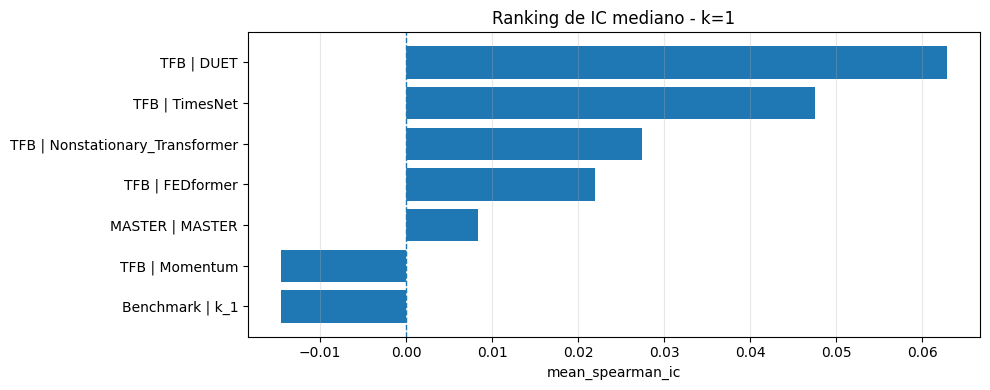

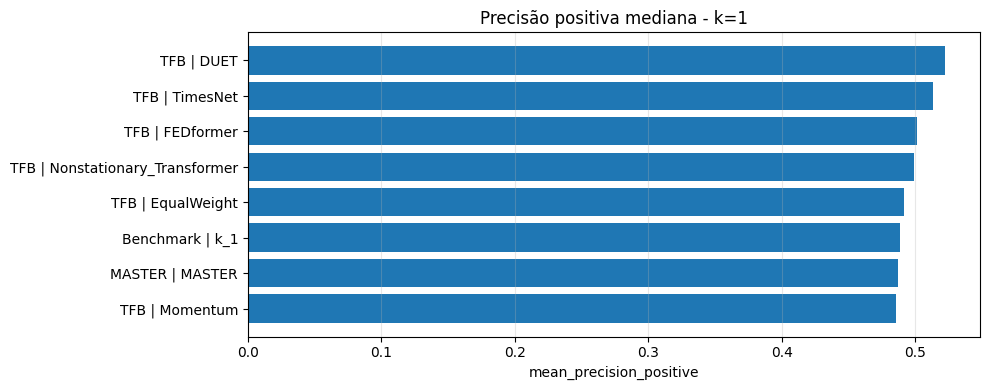

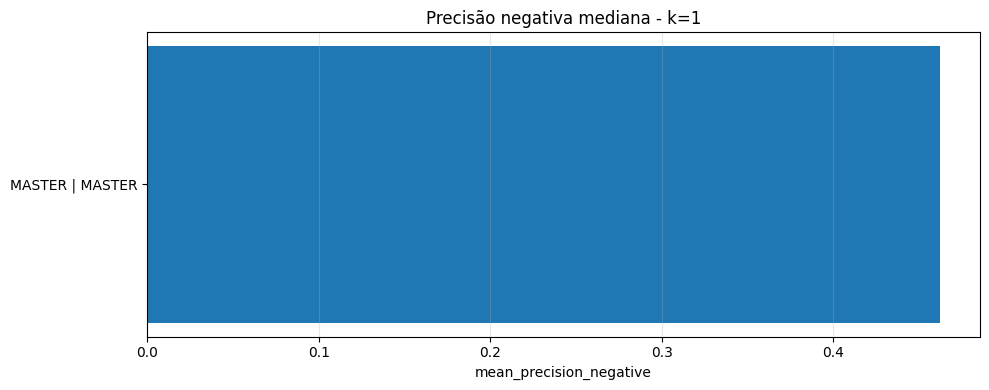

In [13]:
def plot_bar_median(df, metrica, titulo, top_n=30):
    if df.empty or metrica not in df.columns:
        print(f'Sem dados para {metrica}.')
        return None
    base = (df.dropna(subset=[metrica])
              .groupby(['grupo', 'modelo'], dropna=False)[metrica]
              .median().reset_index())
    base['serie'] = base['grupo'].astype(str) + ' | ' + base['modelo'].astype(str)
    base = base.sort_values(metrica, ascending=False).head(top_n).sort_values(metrica)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(base))))
    ax.barh(base['serie'], base[metrica])
    if 'spearman' in metrica:
        ax.axvline(0, linestyle='--', linewidth=1)
    ax.set_xlabel(metrica)
    ax.set_title(titulo)
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    return base

rank_ic = plot_bar_median(k1, 'mean_spearman_ic', 'Ranking de IC mediano - k=1')
rank_pos = plot_bar_median(k1, 'mean_precision_positive', 'Precisão positiva mediana - k=1')
rank_neg = plot_bar_median(k1, 'mean_precision_negative', 'Precisão negativa mediana - k=1')


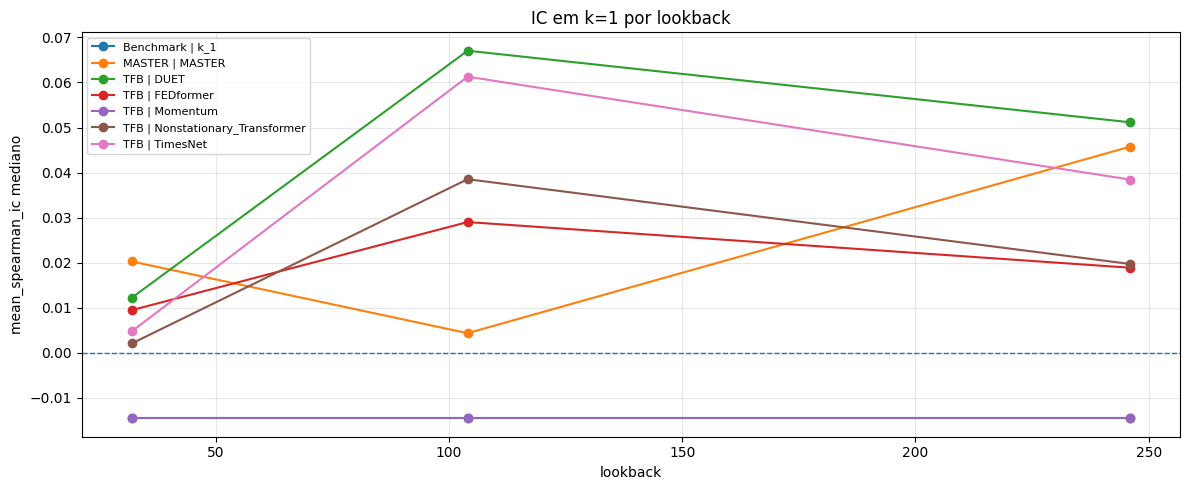

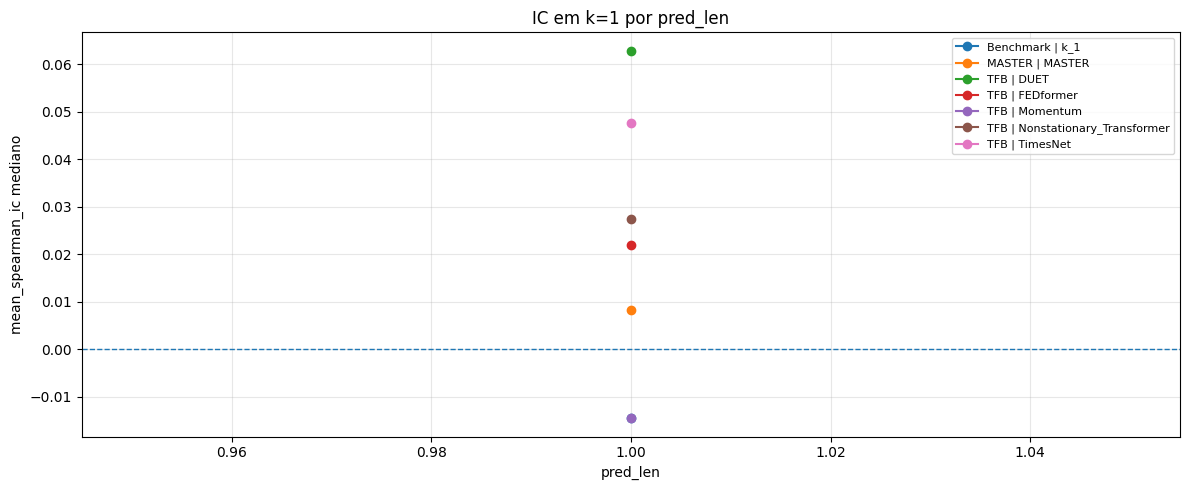

In [14]:
def plot_ic_por_param(df, param, top_n=12):
    if df.empty or param not in df.columns:
        print(f'Sem {param}.')
        return None
    base = df.dropna(subset=['mean_spearman_ic', param]).copy()
    if base.empty:
        print(f'Sem dados para {param}.')
        return None
    ordem = base.groupby('serie_modelo')['mean_spearman_ic'].median().sort_values(ascending=False).head(top_n).index
    base = base[base['serie_modelo'].isin(ordem)]
    agg = base.groupby(['serie_modelo', param], dropna=False)['mean_spearman_ic'].median().reset_index()
    fig, ax = plt.subplots(figsize=(12, 5))
    for serie, g in agg.groupby('serie_modelo'):
        g = g.sort_values(param)
        ax.plot(g[param], g['mean_spearman_ic'], marker='o', label=serie)
    ax.axhline(0, linestyle='--', linewidth=1)
    ax.set_xlabel(param)
    ax.set_ylabel('mean_spearman_ic mediano')
    ax.set_title(f'IC em k=1 por {param}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=8)
    plt.tight_layout()
    plt.show()
    return agg

ic_por_lookback = plot_ic_por_param(k1, 'lookback')
ic_por_predlen = plot_ic_por_param(k1, 'pred_len')


## Saídas salvas

- `simulacoes/comparativo_global_master_tfb/analise_k1_ic_modelos.csv`
- `simulacoes/comparativo_global_master_tfb/top_k1_ic_configuracoes.csv`
